<a href="https://colab.research.google.com/github/paarthbamb/dataScience/blob/main/Unit8/PaarBambUnit8Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
import arviz as az
import xarray as xr
import pymc as pm
import graphviz as gv

!pip install pymc-bart
import pymc_bart as pmb

from sklearn.datasets import fetch_california_housing

# **Unit 8 Project: What drives median housing value in California?**
by Paarth Bamb

**Part I: Context**

California's housing market is one of the most expensive and complex in the United States. Predicting median house values by block group is a classic regression problem, and the non-linear, interactive nature of housing economics makes it a natural fit for a BART model.

I will use **median income (MedInc)**, **median house age (HouseAge)**, **average number of rooms (AveRooms)**, **average occupancy (AveOccup)**, **latitude**, and **longitude** to predict **median house value (MedHouseVal)**, measured in units of $100,000.

The California Housing dataset is derived from the 1990 U.S. Census and aggregates data at the block group level, with 20,640 observations total.

Median house value is strictly positive and right-skewed, which means I should use a Gamma likelihood.

**Part II: Data**

In [ ]:
raw = fetch_california_housing(as_frame=True)
housing = raw.frame
housing.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [ ]:
housing.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='object')

In [ ]:
print(f"Shape: {housing.shape}")
print(f"\nMissing values per column:")
print(housing.isnull().sum())

Shape: (20640, 9)

Missing values per column:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


In [ ]:
cols = ['MedInc', 'HouseAge', 'AveRooms', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']
df = housing[cols].copy()
df.describe()

,MedInc,HouseAge,AveRooms,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,1243.333333,41.950000,-114.310000,5.000010


Now let's look at the pairplot to understand marginal relationships before modeling.

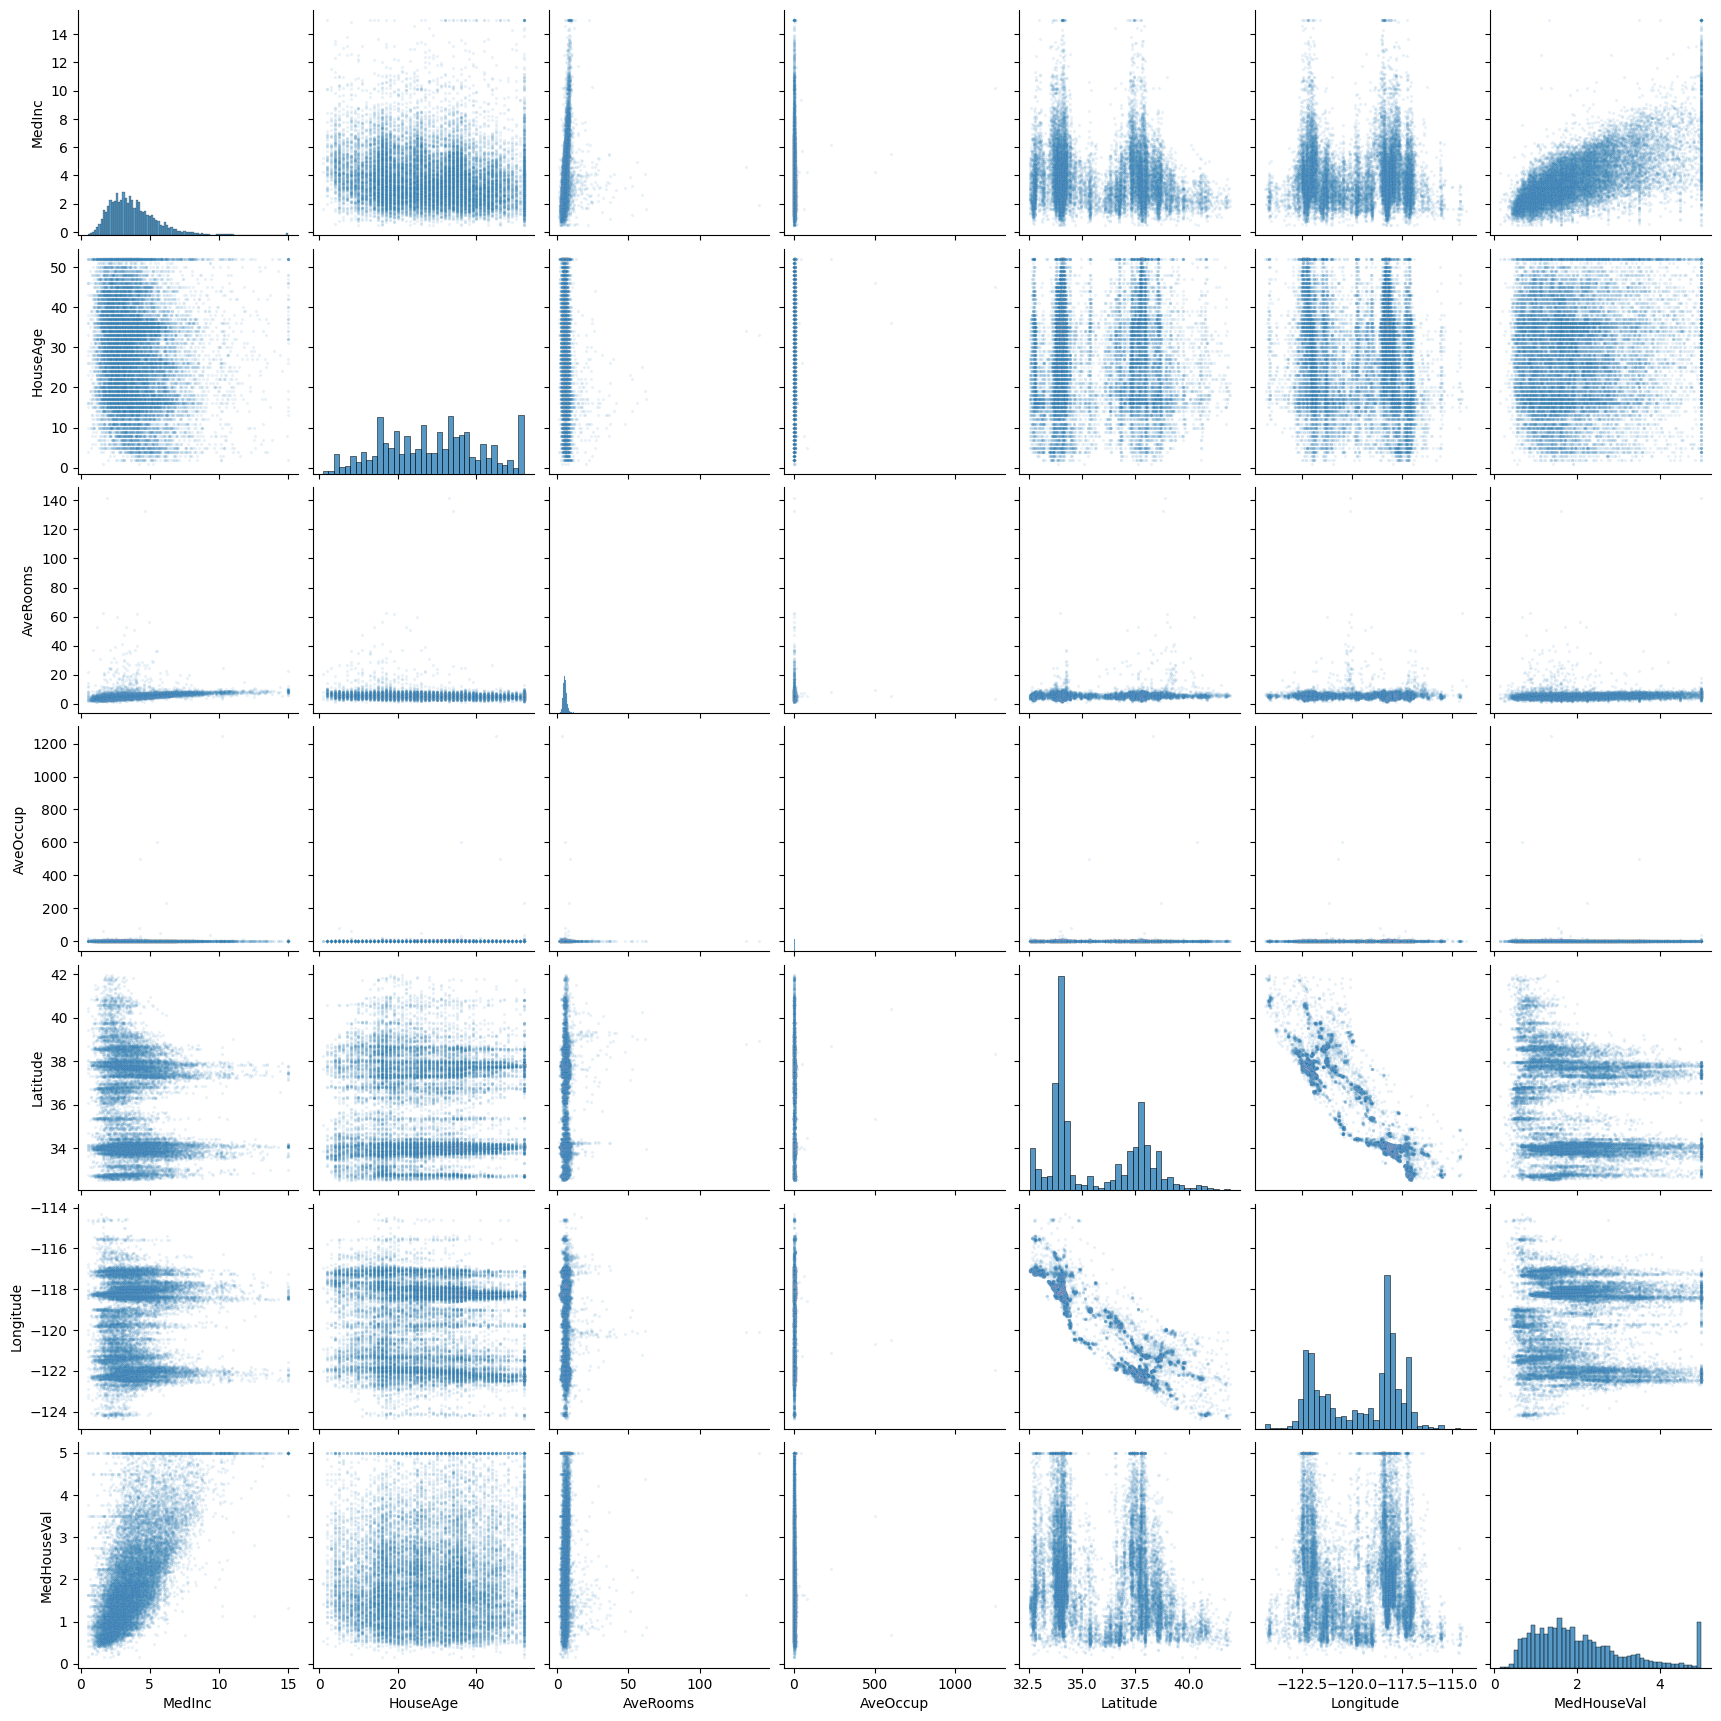

In [ ]:
sns.pairplot(df, plot_kws={'alpha': 0.1, 's': 5})

A few observations from the pairplot:

- MedInc vs MedHouseVal is the clearest positive relationship in the dataset. Higher income neighborhoods command higher home prices, which is not surprising.
- Latitude/Longitude vs MedHouseVal has visible geographic clusters. Coastal and urban areas (lower latitudes, ~-118 longitude, the LA/San Diego corridor) tend to have higher values, suggesting strong spatial structure.
- HouseAge is weakly positive with house value as older housing stock in desirable neighborhoods still commands high prices. Not a clean linear relationship.
- AveRooms vs MedHouseVal is positive but with extreme outliers.
- AveOccup is mostly clustered near low values with outliers.
- Latitude × Longitude clearly work together to define geography. This is the key interaction and we hope BART should capture automatically.

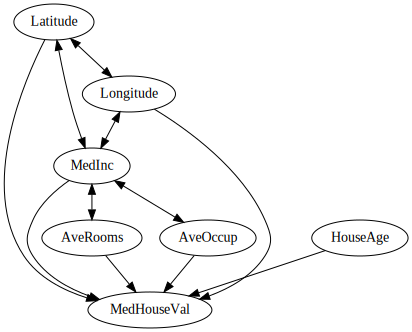

In [ ]:
hdag = gv.Digraph(name="HousingDAG")

hdag.node('V', 'MedHouseVal')
hdag.node('I', 'MedInc')
hdag.node('A', 'HouseAge')
hdag.node('R', 'AveRooms')
hdag.node('O', 'AveOccup')
hdag.node('La', 'Latitude')
hdag.node('Lo', 'Longitude')

hdag.edge('I', 'V')
hdag.edge('A', 'V')
hdag.edge('R', 'V')
hdag.edge('O', 'V')
hdag.edge('La', 'V')
hdag.edge('Lo', 'V')

hdag.edge('La', 'Lo', dir='both') # geographic coords are inherently linked
hdag.edge('I', 'R', dir='both') # wealthier areas tend to have larger homes
hdag.edge('I', 'O', dir='both') # income and overcrowding are negatively correlated
hdag.edge('La', 'I', dir='both') # geography influences local income levels
hdag.edge('Lo', 'I', dir='both')

hdag

**Variable Selection Justification:**

The dataset has 8 features; I kept 6 and dropped AveBedrms and Population.

**Part III: Model**

In [ ]:
X = df[['MedInc', 'HouseAge', 'AveRooms', 'AveOccup', 'Latitude', 'Longitude']]
Y = df['MedHouseVal']

Let's look at the distribution of MedHouseVal before choosing a likelihood.

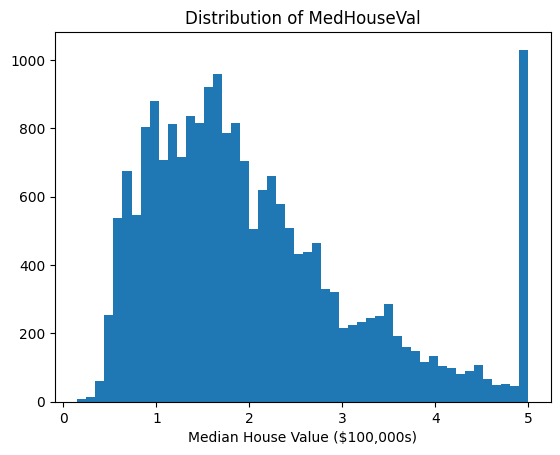

In [ ]:
plt.hist(Y, bins=50)
plt.xlabel('Median House Value ($100,000s)')
plt.title('Distribution of MedHouseVal')
plt.show()

Strictly positive and right-skewed which consistent with a Gamma likelihood. Note the hard cap at 5.0 ($500,000). This is a known artifact of the 1990 Census where top-coded values were capped. This will cause the model to slightly underfit the upper tail, but we'll accept this for the purposes of this analysis.

We use the same log/exp trick from the Unit 8 notes: np.log(Y) into BART (so it operates over the reals), then pm.math.exp the output to recover positive house values.

In [ ]:
with pm.Model() as model_housing:
    s = pm.HalfNormal('s', 1)  # sigma prior and house values are in units of $100k
    μ_ = pmb.BART("μ_", X, np.log(Y), m=50)  # log(Y) so BART stays in real numbers
    μ = pm.Deterministic("μ", pm.math.exp(μ_))  # exponentiate back to house value scale
    y = pm.Gamma("y", mu=μ, sigma=s, observed=Y)  # Gamma likelihood
    idata_housing = pm.sample(compute_convergence_checks=False)

In [ ]:
pm.sample_posterior_predictive(idata_housing, model=model_housing, extend_inferencedata=True)

### Posterior Predictive Check

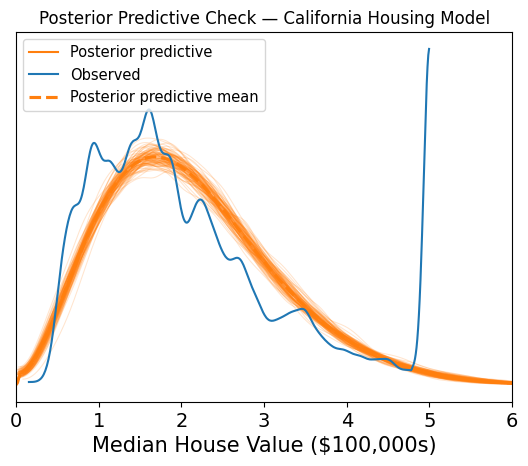

In [ ]:
ax = az.plot_ppc(idata_housing, num_pp_samples=100, colors=["C1", "C0", "C1"])
ax.set_xlim(0, 6)
plt.xlabel('Median House Value ($100,000s)')
plt.title('Posterior Predictive Check — California Housing Model')
plt.show()

### Posterior Mean Plot (MedInc vs MedHouseVal)

In [ ]:
posterior_mean = idata_housing.posterior["μ"]

μ_hdi = az.hdi(ary=idata_housing, group="posterior", var_names=["μ"], hdi_prob=0.74)

pps = az.extract(
    idata_housing, group="posterior_predictive", var_names=["y"]
).T

/usr/local/lib/python3.12/dist-packages/arviz/plots/hdiplot.py:166: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_data = hdi(y, hdi_prob=hdi_prob, circular=circular, multimodal=False, **hdi_kwargs)


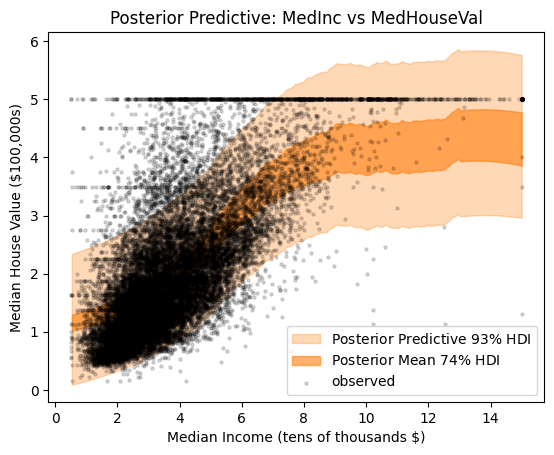

In [ ]:
# Plot posterior predictive vs. MedInc (the strongest predictor)
idx = np.argsort(X['MedInc'].to_numpy())
fig, ax = plt.subplots()

az.plot_hdi(
    x=X['MedInc'].to_numpy(),
    y=pps,
    ax=ax,
    hdi_prob=0.93,
    fill_kwargs={"alpha": 0.3, "label": r"Posterior Predictive $93\%$ HDI"},
)

az.plot_hdi(
    x=X['MedInc'].to_numpy(),
    y=posterior_mean,
    ax=ax,
    hdi_prob=0.74,
    fill_kwargs={"alpha": 0.6, "label": r"Posterior Mean $74\%$ HDI"},
)

ax.scatter(X['MedInc'].to_numpy(), Y.to_numpy(), s=5, alpha=0.15, label="observed", c='black')
ax.set_xlabel("Median Income (tens of thousands $)")
ax.set_ylabel("Median House Value ($100,000s)")
ax.set_title("Posterior Predictive: MedInc vs MedHouseVal")
ax.legend()
plt.show()

This plot shows the posterior predictive mean (darker band) and 93% HDI (lighter band) for house value as a function of median income. The relationship is clearly positive and non-linear which is consistent with what we saw in the pairplot. The wider bands at the right edge reflect BART's known tendency toward "flatness" at the boundaries of the predictor range, as discussed in the Unit 8 notes: since BART is constructed from horizontal and vertical lines, it becomes uncertain at the edges of the training data.

# PDP

PDPs show the marginal association between each predictor and median house value, averaged over all other predictors.

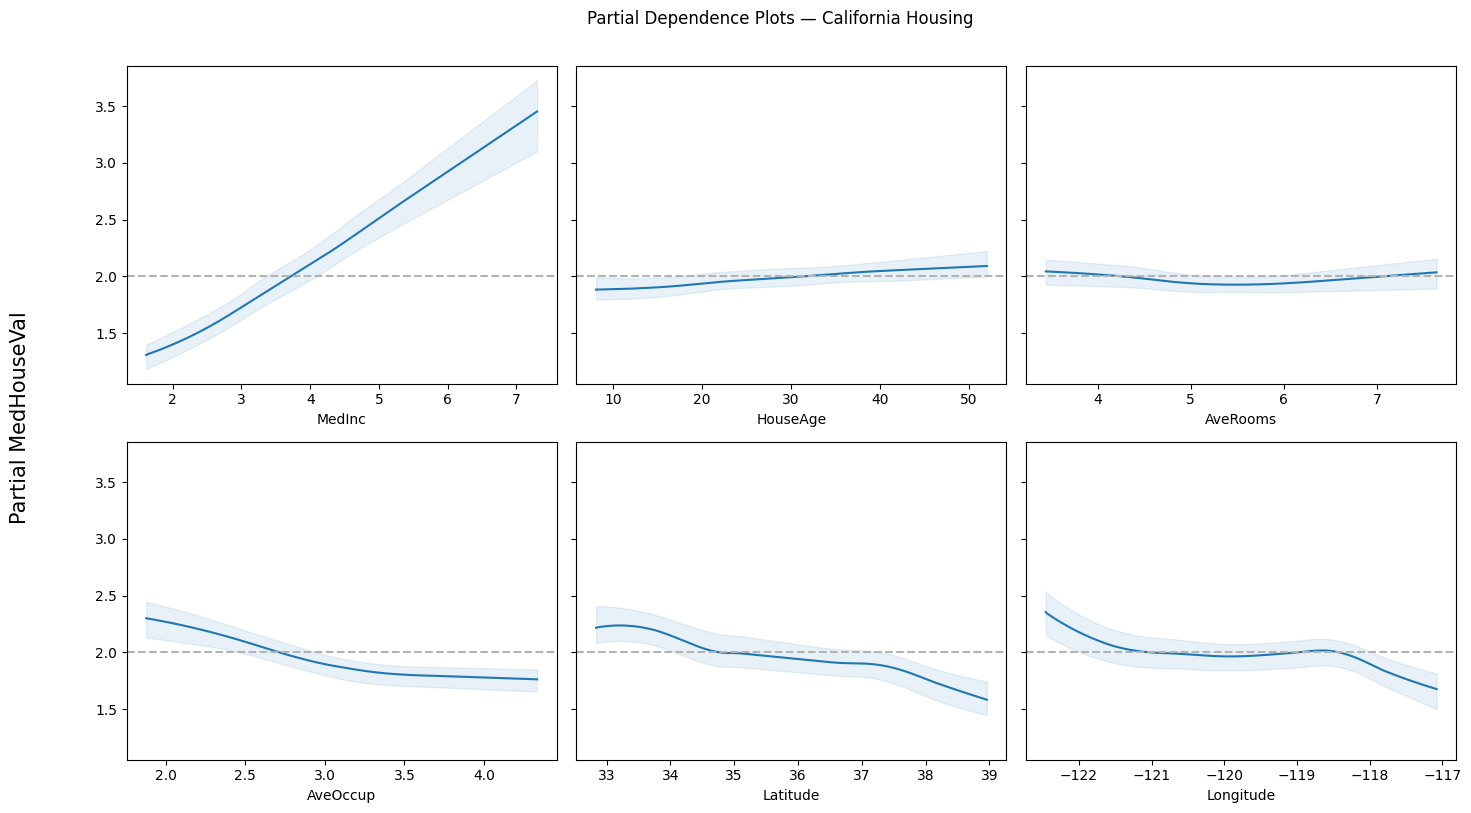

In [ ]:
pmb.plot_pdp(μ_, X, Y, grid=(2, 3), func=np.exp, figsize=(14, 8))
plt.suptitle("Partial Dependence Plots — California Housing", y=1.01)
plt.tight_layout()
plt.show()

**PDP Interpretation:**

- MedInc has a strong, accelerating positive trend, which is the largest marginal effect of any predictor. This confirms median income as the dominant driver of house value in the model.

# ICE Plot

ICE plots drop the independence assumption. Rather than averaging over all observations, they trace each individual block group's predicted house value as one predictor varies, with all other predictors held at that block group's actual values.

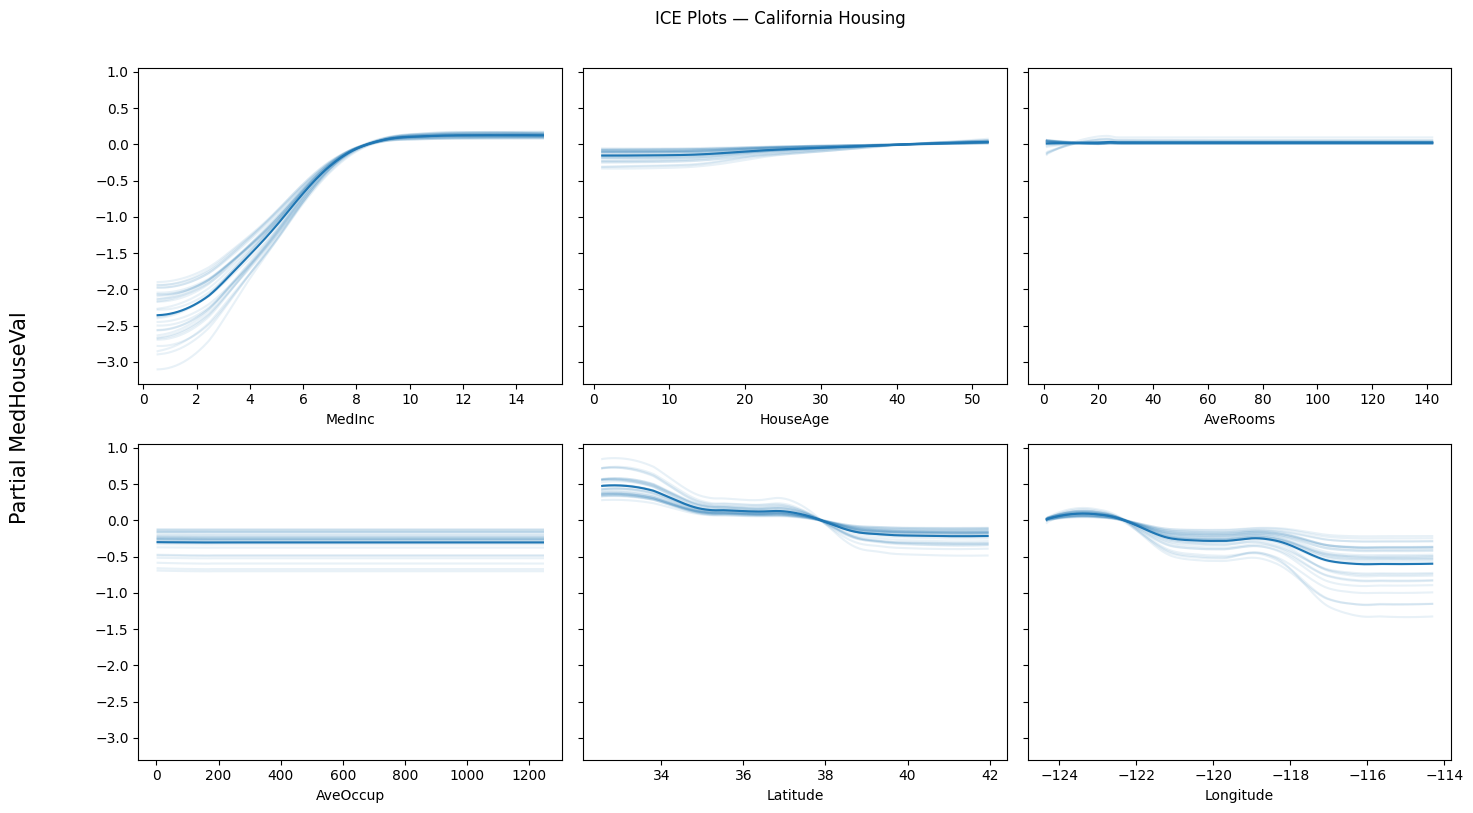

In [ ]:
pmb.plot_ice(μ_, X, Y, grid=(2, 3), func=np.exp, figsize=(14, 8))
plt.suptitle("ICE Plots", y=1.01)
plt.tight_layout()
plt.show()

**ICE Plot Interpretation:**

- MedInc's Lines fan out substantially at higher income values. This is evidence of the MedInc × Latitude/Longitude interaction as the effect of increasing income on house value is much steeper in coastal, high-demand markets (where a small income advantage translates to large price differences) than in inland areas.

### Variable Importance (VI) Plot

VI plots provide a numerical argument for variable selection. High-VI variables were actively and heavily used by BART's tree structure to reduce prediction error. Low-VI variables could potentially be dropped for a leaner model without much loss in accuracy.

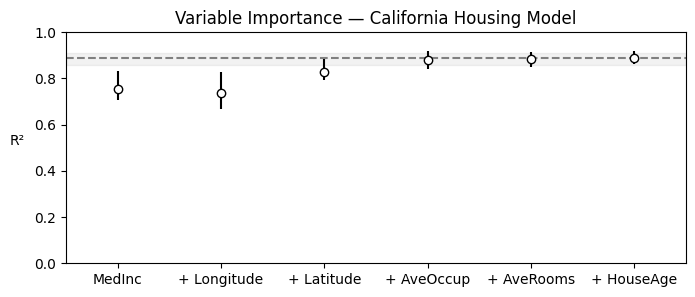

In [ ]:
vi_housing = pmb.compute_variable_importance(idata_housing, μ_, X)
pmb.plot_variable_importance(vi_housing)
plt.title("Variable Importance — California Housing Model")
plt.show()

**VI Interpretation:**

I expect the VI plot to rank roughly as: **MedInc > Longitude > Latitude > AveOccup > AveRooms > HouseAge**.

MedInc should dominate because income is the single strongest predictor visible in the pairplot and PDPs. Latitude and Longitude should rank highly because California's geographic variation accounts for enormous differences in property value.

**Part IV: Conclusion**

The posterior predictive check showed the model capturing the bulk of the house value distribution well. The slight underfit near the $500,000 ceiling is a feature rather than a failure.

The dataset is from 1990, so findings don't directly translate to California's current housing market.

Credit to Claude for helping me understand and phrase some parts of this project.